# Cinemath ML Notebook
### Imports

In [1]:
import os, ast, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    r2_score, mean_squared_error,
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    RandomForestClassifier, GradientBoostingClassifier
)


# Step 1 — Data Loading (Past 10 Years, Random Sampling)

In [2]:
base = os.path.dirname(os.getcwd())

# ── LOAD MOVIES — filter to past 10 years first ───────────────────────────
movie_files = [
    os.path.join(base, 'final_data', 'tmdb_movie_data', 'movie_data_part1.csv'),
    os.path.join(base, 'final_data', 'tmdb_movie_data', 'movie_data_part2.csv')
]
df_movies_raw = pd.concat([pd.read_csv(f) for f in movie_files], ignore_index=True)

CURRENT_YEAR = datetime.datetime.now().year
YEAR_CUTOFF  = CURRENT_YEAR - 10

if 'release_year_x' in df_movies_raw.columns:
    df_movies_raw['_year'] = df_movies_raw['release_year_x']
elif 'release_year_y' in df_movies_raw.columns:
    df_movies_raw['_year'] = df_movies_raw['release_year_y']
else:
    df_movies_raw['_year'] = pd.to_numeric(
        df_movies_raw.get('release_date', pd.Series(dtype=str)).str[:4], errors='coerce'
    )

df_movies = df_movies_raw[df_movies_raw['_year'] >= YEAR_CUTOFF].copy()
df_movies = df_movies.drop(columns=['_year']).drop_duplicates(subset=['tmdb_id'])
print(f'Year cutoff        : {YEAR_CUTOFF}')
print(f'Movies after filter: {len(df_movies):,}')

# ── RANDOM SAMPLE: movies meeting minimum vote threshold ──────────────────
VOTE_THRESHOLD = 50
df_movies_sampled = (
    df_movies[df_movies['vote_count'] >= VOTE_THRESHOLD].copy()
    if 'vote_count' in df_movies.columns else df_movies.copy()
)
SAMPLE_SIZE = min(30_000, len(df_movies_sampled))
df_movies_sampled = df_movies_sampled.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
valid_tmdb_ids = set(df_movies_sampled['tmdb_id'])
print(f'After threshold    : {len(df_movies_sampled):,}  (sample of {SAMPLE_SIZE:,})')

# ── LOAD LETTERBOXD ───────────────────────────────────────────────────────
cleaned_path = os.path.join(base, 'final_data', 'letterboxd_review_data',
                            'final_data', 'letterboxd_review_data', 'cleaned_data')
review_files = sorted([os.path.join(cleaned_path, f)
                       for f in os.listdir(cleaned_path) if f.endswith('.csv')])
df_letter = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
df_letter  = df_letter[df_letter['tmdb_id'].isin(valid_tmdb_ids)].copy()

# ── LOAD DESCRIPTION DATA ─────────────────────────────────────────────────
desc_path  = os.path.join(base, 'final_data', 'final_tmdb_movie_data')
desc_files = sorted([os.path.join(desc_path, f)
                     for f in os.listdir(desc_path) if f.endswith('.csv')])
df_desc = pd.concat([pd.read_csv(f) for f in desc_files], ignore_index=True)
df_desc  = df_desc[df_desc['tmdb_id'].isin(valid_tmdb_ids)].copy()

print(f'Letterboxd shape   : {df_letter.shape}')
print(f'Desc shape         : {df_desc.shape}')


Year cutoff        : 2016
Movies after filter: 90,782
After threshold    : 9,983  (sample of 9,983)
Letterboxd shape   : (1492016, 14)
Desc shape         : (9983, 5)


# Step 1b — Data Cleaning & Pre-processing

In [3]:
# ── LETTERBOXD: engagement count only — no ratings ────────────────────────
LETTER_DROP = ['actors_url', 'director_url', 'rating', 'genre']
df_letter = df_letter.drop(columns=[c for c in LETTER_DROP if c in df_letter.columns])
df_letter = df_letter.drop_duplicates(subset=['username', 'tmdb_id'])
review_count = df_letter.groupby('tmdb_id').size().reset_index(name='num_letterboxd_reviews')

# ── MOVIES: drop ratings + identifiers ───────────────────────────────────
MOVIES_DROP = [
    'vote_average', 'vote_count', 'popularity',
    'revenue_x', 'revenue_y', 'profit_x', 'profit_y', 'profit_margin', 'budget_per_min',
    'budget_x', 'budget_y', 'runtime_y', 'original_language_y', 'in_franchise_y',
    'release_year_x', 'release_year_y', 'movie_id', 'release_date', 'director_name',
    'production_countries', 'production_country_group', 'production_companies',
    'belongs_to_collection', 'has_imdb', 'has_facebook', 'has_instagram', 'has_twitter',
    'social_media_count', 'producer_count', 'release_month', 'n_production_countries',
]
df_movies_sampled = df_movies_sampled.drop(
    columns=[c for c in MOVIES_DROP if c in df_movies_sampled.columns]
).drop_duplicates(subset=['tmdb_id'])

# ── DESCRIPTION: cast features ────────────────────────────────────────────
df_desc['overview']  = df_desc['overview'].fillna('').str.strip()
df_desc['tagline']   = df_desc['tagline'].fillna('').str.strip()
df_desc['full_cast'] = df_desc['full_cast'].fillna('[]')
df_desc['overview_word_count'] = df_desc['overview'].apply(lambda x: len(x.split()) if x else 0)
df_desc['tagline_word_count']  = df_desc['tagline'].apply(lambda x: len(x.split()) if x else 0)

def extract_cast_pop(cast_str):
    try:
        cast = ast.literal_eval(cast_str) if isinstance(cast_str, str) else cast_str
        pops = sorted([c.get('popularity', 0) for c in cast], reverse=True)
        return (pops[0] if len(pops) > 0 else 0,
                pops[1] if len(pops) > 1 else 0,
                pops[2] if len(pops) > 2 else 0)
    except:
        return 0, 0, 0

cast_pops = df_desc['full_cast'].apply(extract_cast_pop)
df_desc['desc_cast_1_popularity'] = cast_pops.apply(lambda x: x[0])
df_desc['desc_cast_2_popularity'] = cast_pops.apply(lambda x: x[1])
df_desc['desc_cast_3_popularity'] = cast_pops.apply(lambda x: x[2])
df_desc['desc_cast_total'] = (df_desc['desc_cast_1_popularity'] +
                               df_desc['desc_cast_2_popularity'] +
                               df_desc['desc_cast_3_popularity'])
df_desc['desc_cast_max'] = df_desc[['desc_cast_1_popularity',
                                     'desc_cast_2_popularity',
                                     'desc_cast_3_popularity']].max(axis=1)
df_desc = df_desc.drop_duplicates(subset=['tmdb_id'])

# ── FULL CAST: extract top-N actor names for one-hot encoding ─────────────
TOP_CAST_N = 10   # keep the top-N billed actors per movie

def extract_actor_names(cast_str, n=TOP_CAST_N):
    try:
        cast = ast.literal_eval(cast_str) if isinstance(cast_str, str) else cast_str
        # sort by 'order' (billing order) if present, else take as-is
        cast_sorted = sorted(cast, key=lambda c: c.get('order', 999))
        return [c['name'] for c in cast_sorted[:n] if 'name' in c]
    except:
        return []

df_desc['cast_names'] = df_desc['full_cast'].apply(extract_actor_names)

print('df_movies_sampled :', df_movies_sampled.shape)
print('df_desc           :', df_desc.shape)


df_movies_sampled : (9983, 29)
df_desc           : (9983, 13)


In [4]:
# ── MERGE + ENGINEER HUMAN-INTUITION FEATURES ────────────────────────────
df_main = df_movies_sampled.merge(review_count, on='tmdb_id', how='left')
df_main['num_letterboxd_reviews'] = df_main['num_letterboxd_reviews'].fillna(0)

# ── GENRE: most common per movie, fill missing with global mode (not Unknown) ─
cleaned_path = os.path.join(base, 'final_data', 'letterboxd_review_data',
                            'final_data', 'letterboxd_review_data', 'cleaned_data')
review_files_genre = sorted([os.path.join(cleaned_path, f)
                              for f in os.listdir(cleaned_path) if f.endswith('.csv')])
df_letter_genre = pd.concat([pd.read_csv(f) for f in review_files_genre], ignore_index=True)
df_letter_genre  = df_letter_genre[df_letter_genre['tmdb_id'].isin(valid_tmdb_ids)][['tmdb_id','genre']].dropna()
genre_mode = (
    df_letter_genre.groupby('tmdb_id')['genre']
    .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
    .reset_index().rename(columns={'genre': 'primary_genre'})
)
df_main = df_main.merge(genre_mode, on='tmdb_id', how='left')
global_genre_mode = df_letter_genre['genre'].mode().iloc[0]
df_main['primary_genre'] = df_main['primary_genre'].fillna(global_genre_mode)

# ── DESCRIPTION MERGE ─────────────────────────────────────────────────────
df_main = df_main.merge(
    df_desc[['tmdb_id', 'overview', 'tagline', 'full_cast', 'cast_names',
             'overview_word_count', 'tagline_word_count',
             'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity',
             'desc_cast_total', 'desc_cast_max']],
    on='tmdb_id', how='left'
)
for col in ['overview', 'tagline', 'full_cast']:
    df_main[col] = df_main[col].fillna('')
df_main['cast_names'] = df_main['cast_names'].apply(lambda x: x if isinstance(x, list) else [])
for col in ['overview_word_count', 'tagline_word_count', 'desc_cast_1_popularity',
            'desc_cast_2_popularity', 'desc_cast_3_popularity', 'desc_cast_total', 'desc_cast_max']:
    df_main[col] = df_main[col].fillna(0)

# ── STRUCTURED HUMAN-INTUITION FEATURES ──────────────────────────────────
df_main['has_tagline']   = (df_main['tagline'].str.strip() != '').astype(int)
df_main['has_overview']  = (df_main['overview'].str.strip() != '').astype(int)
df_main['overview_depth'] = pd.cut(df_main['overview_word_count'],
    bins=[-1, 30, 80, float('inf')], labels=[0, 1, 2]).astype(int)
df_main['tagline_style'] = pd.cut(df_main['tagline_word_count'],
    bins=[-1, 0, 8, float('inf')], labels=[0, 1, 2]).astype(int)

def count_cast(cast_str):
    try: return len(ast.literal_eval(cast_str) if isinstance(cast_str, str) else [])
    except: return 0
df_main['cast_size']        = df_main['full_cast'].apply(count_cast)
df_main['is_ensemble_film'] = (df_main['cast_size'] >= 10).astype(int)
df_main['star_power_tier']  = pd.cut(df_main['desc_cast_max'],
    bins=[-1, 5, 20, float('inf')], labels=[0, 1, 2]).astype(int)
df_main['ensemble_richness'] = (
    (df_main['desc_cast_1_popularity'] > 5).astype(int) +
    (df_main['desc_cast_2_popularity'] > 5).astype(int) +
    (df_main['desc_cast_3_popularity'] > 5).astype(int)
)
df_main['marketing_completeness'] = (
    df_main['has_tagline'] + df_main['has_overview'] +
    (df_main['desc_cast_max'] > 0).astype(int)
)
df_main['buzz_score'] = np.log1p(df_main['num_letterboxd_reviews'])
df_main = df_main.drop(columns=['tmdb_id'], errors='ignore')

print('df_main shape  :', df_main.shape)
print('df_main columns:', df_main.columns.tolist())


df_main shape  : (9983, 50)
df_main columns: ['release_decade', 'movie_age', 'name', 'runtime_x', 'in_franchise_x', 'original_language_x', 'release_type', 'production_company_count', 'is_major_studio', 'is_us_production', 'cast_size', 'cast_1_popularity', 'cast_2_popularity', 'cast_3_popularity', 'director_popularity', 'director_prior_films', 'keywords', 'keyword_count', 'kw_independent_film', 'kw_animation', 'kw_superhero', 'kw_remake', 'kw_based_on_true_story', 'kw_sequel', 'kw_based_on_novel', 'kw_documentary', 'kw_direct-to-video', 'star_power', 'num_letterboxd_reviews', 'primary_genre', 'overview', 'tagline', 'full_cast', 'cast_names', 'overview_word_count', 'tagline_word_count', 'desc_cast_1_popularity', 'desc_cast_2_popularity', 'desc_cast_3_popularity', 'desc_cast_total', 'desc_cast_max', 'has_tagline', 'has_overview', 'overview_depth', 'tagline_style', 'is_ensemble_film', 'star_power_tier', 'ensemble_richness', 'marketing_completeness', 'buzz_score']


# Step 1c — TF-IDF + SVD Text Features

Builds 20 latent text dimensions from all movie text. Run the inspect + heatmap cells below to name each one before training.

In [5]:
# ── BUILD TF-IDF + SVD ───────────────────────────────────────────────────
df_main['name']     = df_main['name'].fillna('')
df_main['keywords'] = df_main['keywords'].fillna('')

df_main['_all_text'] = (
    df_main['name']             + ' ' +
    df_main['keywords']         + ' ' +
    df_main['overview']         + ' ' +
    df_main['tagline']          + ' ' +
    df_main['primary_genre']
)

tfidf = TfidfVectorizer(max_features=150, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_main['_all_text'])
vocab = np.array(tfidf.get_feature_names_out())

N_COMPONENTS = 20
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

print(f'TF-IDF matrix     : {tfidf_matrix.shape}')
print(f'After SVD         : {tfidf_reduced.shape}')
print(f'Variance explained: {svd.explained_variance_ratio_.sum():.2%}')


TF-IDF matrix     : (9983, 150)
After SVD         : (9983, 20)
Variance explained: 29.50%


In [6]:
# ── INSPECT: top words per SVD component ─────────────────────────────────
# Read this to understand what theme each dimension captured.
print(f'{"Component":<12} {"Var":>6}   Top 8 words')
print('-' * 70)
top_words_per_component = {}
for i, component in enumerate(svd.components_):
    top_idx   = component.argsort()[-8:][::-1]
    top_words = vocab[top_idx].tolist()
    top_words_per_component[i] = top_words
    print(f'SVD_{i:02d}      {svd.explained_variance_ratio_[i]:>5.2%}   {", ".join(top_words)}')


Component       Var   Top 8 words
----------------------------------------------------------------------
SVD_00      0.67%   drama, life, family, based, comedy, love, story, new
SVD_01      2.48%   story, based, true, war, drama, documentary, novel, book
SVD_02      2.08%   comedy, story, documentary, true, based, world, special, war
SVD_03      1.94%   love, romance, drama, relationship, life, woman, christmas, school
SVD_04      1.87%   documentary, life, music, film, footage, director, woman, drama
SVD_05      1.81%   christmas, family, documentary, holiday, story, romance, movie, true
SVD_06      1.69%   family, drama, war, father, son, comedy, daughter, mother
SVD_07      1.65%   war, world, action, school, animation, high, new, time
SVD_08      1.56%   school, high, family, year, old, based, girl, animation
SVD_09      1.47%   drama, war, horror, christmas, woman, school, young, director
SVD_10      1.43%   horror, love, family, war, world, romance, supernatural, house
SVD_11    

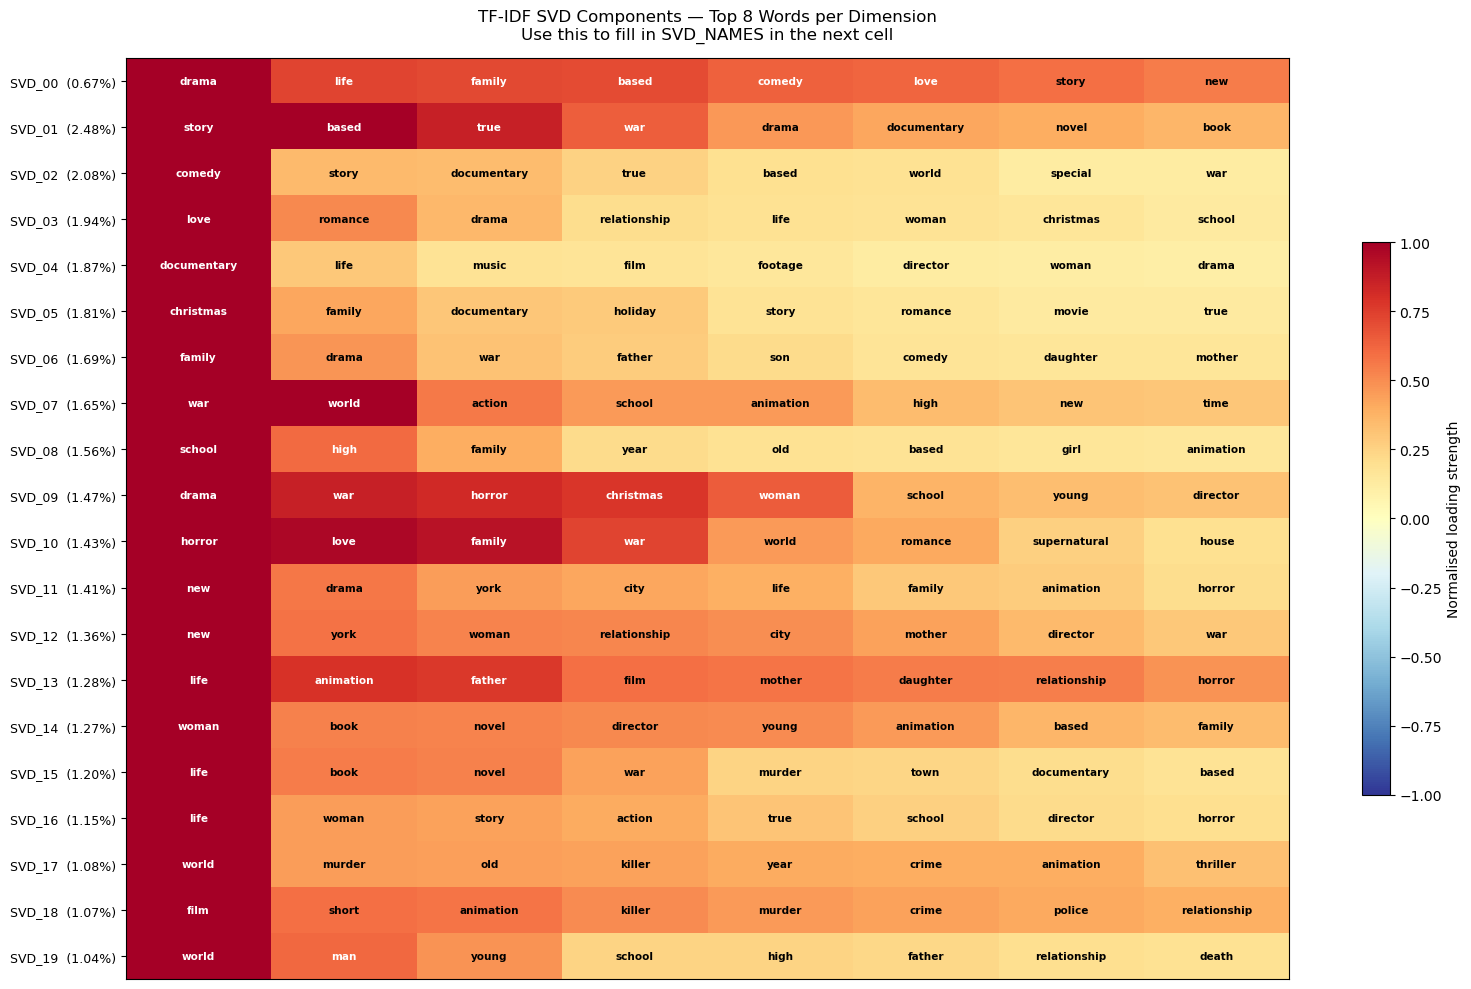

In [7]:
# ── HEATMAP: word loadings per component ─────────────────────────────────
# Darker red = strong positive loading. Use this + the print above to NAME each component.
N_WORDS = 8
loading_matrix = np.zeros((N_COMPONENTS, N_WORDS))
all_top_words  = []
for i in range(N_COMPONENTS):
    component = svd.components_[i]
    top_idx   = component.argsort()[-N_WORDS:][::-1]
    all_top_words.append(vocab[top_idx].tolist())
    loading_matrix[i] = component[top_idx]

row_max      = np.abs(loading_matrix).max(axis=1, keepdims=True)
loading_norm = loading_matrix / np.where(row_max == 0, 1, row_max)

fig, ax = plt.subplots(figsize=(16, 10))
im = ax.imshow(loading_norm, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
ylabels = [f'SVD_{i:02d}  ({svd.explained_variance_ratio_[i]:.2%})' for i in range(N_COMPONENTS)]
ax.set_yticks(range(N_COMPONENTS))
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_xticks([])
for col in range(N_WORDS):
    for row in range(N_COMPONENTS):
        word  = all_top_words[row][col]
        color = 'white' if abs(loading_norm[row, col]) > 0.6 else 'black'
        ax.text(col, row, word, ha='center', va='center', fontsize=7.5,
                color=color, fontweight='bold')
ax.set_title('TF-IDF SVD Components — Top 8 Words per Dimension\n'
             'Use this to fill in SVD_NAMES in the next cell', fontsize=12, pad=14)
plt.colorbar(im, ax=ax, shrink=0.6, label='Normalised loading strength')
plt.tight_layout()
plt.show()


In [8]:
# ── RENAME SVD COMPONENTS ────────────────────────────────────────────────
# After reading the heatmap + print above, update these names to match what YOU see.
# Set any component to None to DROP it from the feature set.

SVD_NAMES = {
    0:  'theme_general_context',
    1:  'theme_action_adventure',
    2:  'theme_drama_emotion',
    3:  'theme_horror_dark',
    4:  'theme_romance_family',
    5:  'theme_scifi_fantasy',
    6:  'theme_comedy_light',
    7:  'theme_crime_thriller',
    8:  'theme_language_region',
    9:  'theme_prestige_awards',
    10: 'theme_franchise_sequel',
    11: 'theme_cast_star_power',
    12: None,
    13: None,
    14: None,
    15: None,
    16: None,
    17: None,
    18: None,
    19: None,
}

named_cols = {name: tfidf_reduced[:, idx]
              for idx, name in SVD_NAMES.items() if name is not None}
tfidf_df = pd.DataFrame(named_cols, index=df_main.index)
df_main  = df_main.drop(columns=['_all_text'], errors='ignore')

print(f'SVD kept   : {len(tfidf_df.columns)} / {N_COMPONENTS}')
print(f'SVD dropped: {N_COMPONENTS - len(tfidf_df.columns)}')
print('Kept:')
for col in tfidf_df.columns:
    print(f'  theme -> {col}')


SVD kept   : 12 / 20
SVD dropped: 8
Kept:
  theme -> theme_general_context
  theme -> theme_action_adventure
  theme -> theme_drama_emotion
  theme -> theme_horror_dark
  theme -> theme_romance_family
  theme -> theme_scifi_fantasy
  theme -> theme_comedy_light
  theme -> theme_crime_thriller
  theme -> theme_language_region
  theme -> theme_prestige_awards
  theme -> theme_franchise_sequel
  theme -> theme_cast_star_power


# Step 1d — Encode + Build Final Feature Set

In [9]:
cat_cols = ['release_type']
# original_language_x removed — testing model without any language features
# primary_genre intentionally excluded — genre is already captured in the
# named SVD theme components (theme_drama_emotion, theme_action_adventure etc.)
# One-hot encoding it causes leakage: the global-mode fill (Drama) gets
# applied to all zero-review movies, making primary_genre_Drama a proxy
# for 'this movie had no buzz' — i.e. the target itself.
cat_cols = [c for c in cat_cols if c in df_main.columns]
df_encoded = pd.get_dummies(df_main, columns=cat_cols)

# Drop primary_genre_Unknown — leakage
unknown_cols = [c for c in df_encoded.columns if 'unknown' in c.lower()]
if unknown_cols:
    df_encoded = df_encoded.drop(columns=unknown_cols)
    print(f'Dropped leakage cols: {unknown_cols}')

# ── ONE-HOT ENCODE full_cast (top actors) ────────────────────────────────
if 'cast_names' in df_main.columns:
    mlb = MultiLabelBinarizer()
    cast_ohe = pd.DataFrame(
        mlb.fit_transform(df_main['cast_names']),
        columns=[f'actor_{n.replace(" ", "_")}' for n in mlb.classes_],
        index=df_main.index
    )
    # Drop extremely rare actors (appear in < 0.1% of films) to control dimensionality
    min_appearances = max(2, int(len(df_main) * 0.001))
    cast_ohe = cast_ohe.loc[:, cast_ohe.sum() >= min_appearances]
    df_main = pd.concat([df_main, cast_ohe], axis=1)
    print(f'Cast OHE columns added: {cast_ohe.shape[1]}')

DROP_TEXT = ['name', 'keywords', '_all_text', 'overview', 'tagline',
             'full_cast', 'cast_names', 'spoken_languages', 'release_decade', 'primary_genre']
df_encoded = df_encoded.drop(columns=[c for c in DROP_TEXT if c in df_encoded.columns])

bool_cols = df_encoded.select_dtypes(include=['bool']).columns.tolist()
obj_cols  = df_encoded.select_dtypes(include=['object']).columns.tolist()
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
for col in obj_cols:
    df_encoded[col] = pd.to_numeric(df_encoded[col], errors='coerce').fillna(0).astype(int)

df_numeric = df_encoded.select_dtypes(include=[np.number]).fillna(0)
df_final   = pd.concat([df_numeric, tfidf_df], axis=1)

RATING_KEYWORDS = ['rating', 'log_', 'director_avg', 'genre_avg']
leaked = [c for c in df_final.columns if any(kw in c.lower() for kw in RATING_KEYWORDS)]
if leaked:
    print(f'WARNING — dropping: {leaked}')
    df_final = df_final.drop(columns=leaked)
else:
    print('OK — no rating-related columns.')

print(f'df_final shape: {df_final.shape}')
print('All features:')
for c in sorted(df_final.columns): print(f'  {c}')


Cast OHE columns added: 1227
OK — no rating-related columns.
df_final shape: (9983, 55)
All features:
  buzz_score
  cast_1_popularity
  cast_2_popularity
  cast_3_popularity
  cast_size
  desc_cast_1_popularity
  desc_cast_2_popularity
  desc_cast_3_popularity
  desc_cast_max
  desc_cast_total
  director_popularity
  director_prior_films
  ensemble_richness
  has_overview
  has_tagline
  in_franchise_x
  is_ensemble_film
  is_major_studio
  is_us_production
  keyword_count
  kw_animation
  kw_based_on_novel
  kw_based_on_true_story
  kw_direct-to-video
  kw_documentary
  kw_independent_film
  kw_remake
  kw_sequel
  kw_superhero
  marketing_completeness
  movie_age
  num_letterboxd_reviews
  original_language_x
  overview_depth
  overview_word_count
  production_company_count
  release_type_streaming
  release_type_theatrical
  runtime_x
  star_power
  star_power_tier
  tagline_style
  tagline_word_count
  theme_action_adventure
  theme_cast_star_power
  theme_comedy_light
  theme_cri

# Regression Track
Target: `buzz_score` (log of Letterboxd review count)

How much word-of-mouth did this movie generate? Driven by cast, genre, franchise, and plot richness.

In [10]:
REG_TARGET = 'buzz_score'
X_reg = df_final.drop(columns=[REG_TARGET, 'num_letterboxd_reviews'], errors='ignore')
y_reg = df_final[REG_TARGET].values

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled  = scaler_reg.transform(X_reg_test)

print('Regression target  :', REG_TARGET)
print('X_reg_train        :', X_reg_train.shape)
print('X_reg_test         :', X_reg_test.shape)


Regression target  : buzz_score
X_reg_train        : (7487, 53)
X_reg_test         : (2496, 53)


# Classification Track
Target: **Engagement Tier** (Low / Mid / High) from `num_letterboxd_reviews`

What a human considers: cast star power, genre, franchise, plot richness, language — all of which are now in the feature set.

In [11]:
review_counts = df_main['num_letterboxd_reviews']
low_thresh    = review_counts.quantile(0.33)
high_thresh   = review_counts.quantile(0.67)
print(f'Thresholds:  Low <= {low_thresh:.0f}  |  Mid <= {high_thresh:.0f}  |  High > {high_thresh:.0f}')

def reviews_to_tier(n):
    if n <= low_thresh:    return 0
    elif n <= high_thresh: return 1
    else:                  return 2

y_clf = df_main['num_letterboxd_reviews'].apply(reviews_to_tier).values
print('Class distribution:')
unique, counts = np.unique(y_clf, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  {["Low","Mid","High"][u]}: {c} ({c/len(y_clf):.1%})')

X_clf = df_final.drop(columns=['num_letterboxd_reviews', 'buzz_score'], errors='ignore')
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)
scaler_clf = StandardScaler()
X_clf_train_scaled = scaler_clf.fit_transform(X_clf_train)
X_clf_test_scaled  = scaler_clf.transform(X_clf_test)

print('X_clf_train:', X_clf_train.shape)
print('X_clf_test :', X_clf_test.shape)


Thresholds:  Low <= 7  |  Mid <= 73  |  High > 73
Class distribution:
  Low: 3346 (33.5%)
  Mid: 3360 (33.7%)
  High: 3277 (32.8%)
X_clf_train: (7487, 53)
X_clf_test : (2496, 53)


In [12]:
def evaluate_reg(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train R2  : {r2_score(y_train, y_train_pred):.4f}')
    print(f'  Test  R2  : {r2_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}\n')

def evaluate_clf(name, y_train, y_train_pred, y_test, y_test_pred):
    print(f'{name}')
    print(f'  Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}')
    print(f'  Test  Accuracy: {accuracy_score(y_test,  y_test_pred):.4f}')
    print(f'  Test  F1 Score: {f1_score(y_test, y_test_pred, average="weighted"):.4f}\n')

def plot_confusion(name, y_test, y_pred, labels=None):
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(cmap='Blues')
    plt.title(f'{name} -- Confusion Matrix')
    plt.tight_layout()
    plt.show()


# Step 2 — Random Forest (Regression + Classification)

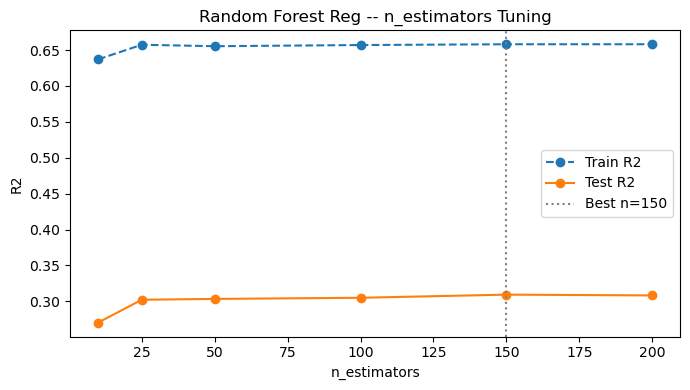

Random Forest Regression (n=150)
  Train R2  : 0.6580
  Test  R2  : 0.3094
  Test  RMSE: 1.8118



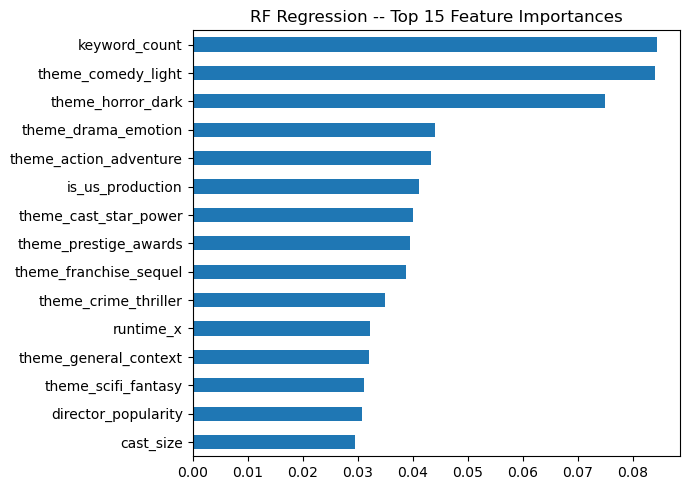

In [13]:
rf_train_r2, rf_test_r2 = [], []
estimator_range = [10, 25, 50, 100, 150, 200]
for n in estimator_range:
    m = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=42, n_jobs=-1)
    m.fit(X_reg_train, y_reg_train)
    rf_train_r2.append(r2_score(y_reg_train, m.predict(X_reg_train)))
    rf_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test)))
best_n_rf = estimator_range[np.argmax(rf_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(estimator_range, rf_train_r2, 'o--', label='Train R2')
plt.plot(estimator_range, rf_test_r2,  'o-',  label='Test R2')
plt.axvline(best_n_rf, color='gray', linestyle=':', label=f'Best n={best_n_rf}')
plt.xlabel('n_estimators'); plt.ylabel('R2')
plt.title('Random Forest Reg -- n_estimators Tuning')
plt.legend(); plt.tight_layout(); plt.show()

rf_reg = RandomForestRegressor(
    n_estimators=best_n_rf, max_depth=10, random_state=42, n_jobs=-1
).fit(X_reg_train, y_reg_train)
evaluate_reg(f'Random Forest Regression (n={best_n_rf})',
    y_reg_train, rf_reg.predict(X_reg_train),
    y_reg_test,  rf_reg.predict(X_reg_test))

pd.Series(rf_reg.feature_importances_, index=X_reg_train.columns)\
  .nlargest(15).sort_values()\
  .plot(kind='barh', figsize=(7, 5), title='RF Regression -- Top 15 Feature Importances')
plt.tight_layout(); plt.show()


Random Forest Classifier -- Engagement Tier (n=150)
  Train Accuracy: 0.8903
  Test  Accuracy: 0.6146
  Test  F1 Score: 0.6125



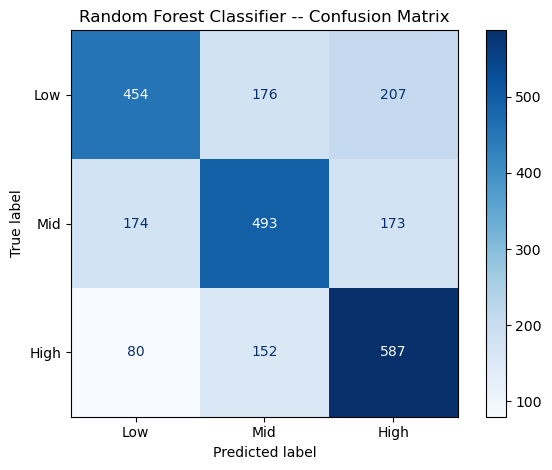

In [14]:
rf_clf = RandomForestClassifier(
    n_estimators=best_n_rf, max_depth=10,
    random_state=42, n_jobs=-1, class_weight='balanced'
).fit(X_clf_train, y_clf_train)
evaluate_clf(f'Random Forest Classifier -- Engagement Tier (n={best_n_rf})',
    y_clf_train, rf_clf.predict(X_clf_train),
    y_clf_test,  rf_clf.predict(X_clf_test))
plot_confusion('Random Forest Classifier', y_clf_test, rf_clf.predict(X_clf_test),
               labels=['Low','Mid','High'])


# Step 3 — Gradient Boosting (Regression + Classification)

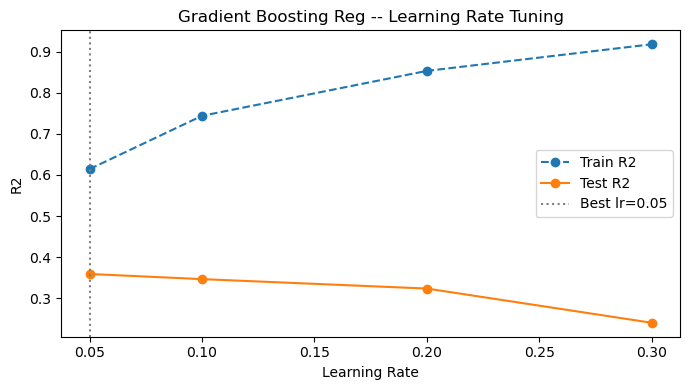

Gradient Boosting Regression (lr=0.05, n=200, depth=5)
  Train R2  : 0.6143
  Test  R2  : 0.3592
  Test  RMSE: 1.7452



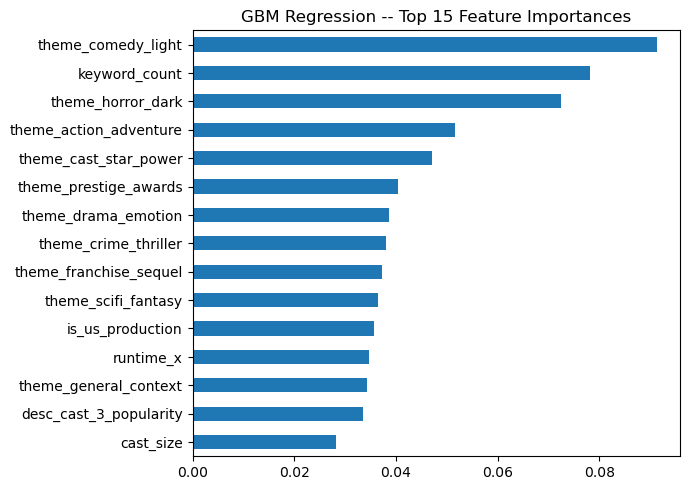

In [15]:
gb_train_r2, gb_test_r2 = [], []
lr_range = [0.05, 0.1, 0.2, 0.3]
for lr_val in lr_range:
    m = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=lr_val,
        subsample=0.8, max_features=0.8, random_state=42
    ).fit(X_reg_train, y_reg_train)
    gb_train_r2.append(r2_score(y_reg_train, m.predict(X_reg_train)))
    gb_test_r2.append(r2_score(y_reg_test,   m.predict(X_reg_test)))
best_lr = lr_range[np.argmax(gb_test_r2)]

plt.figure(figsize=(7, 4))
plt.plot(lr_range, gb_train_r2, 'o--', label='Train R2')
plt.plot(lr_range, gb_test_r2,  'o-',  label='Test R2')
plt.axvline(best_lr, color='gray', linestyle=':', label=f'Best lr={best_lr}')
plt.xlabel('Learning Rate'); plt.ylabel('R2')
plt.title('Gradient Boosting Reg -- Learning Rate Tuning')
plt.legend(); plt.tight_layout(); plt.show()

gb_reg = GradientBoostingRegressor(
    n_estimators=200, max_depth=5, learning_rate=best_lr,
    subsample=0.8, max_features=0.8, random_state=42
).fit(X_reg_train, y_reg_train)
evaluate_reg(f'Gradient Boosting Regression (lr={best_lr}, n=200, depth=5)',
    y_reg_train, gb_reg.predict(X_reg_train),
    y_reg_test,  gb_reg.predict(X_reg_test))

pd.Series(gb_reg.feature_importances_, index=X_reg_train.columns)\
  .nlargest(15).sort_values()\
  .plot(kind='barh', figsize=(7, 5), title='GBM Regression -- Top 15 Feature Importances')
plt.tight_layout(); plt.show()


Gradient Boosting Classifier -- Engagement Tier (lr=0.05, n=200, depth=5)
  Train Accuracy: 0.8723
  Test  Accuracy: 0.6374
  Test  F1 Score: 0.6369



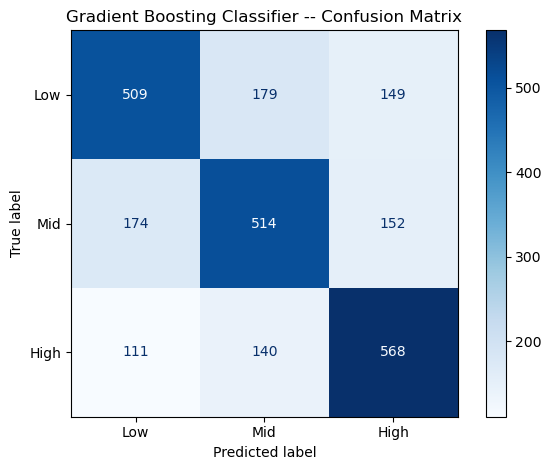

In [16]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200, max_depth=5, learning_rate=best_lr,
    subsample=0.8, max_features=0.8, random_state=42
).fit(X_clf_train, y_clf_train)
evaluate_clf(f'Gradient Boosting Classifier -- Engagement Tier (lr={best_lr}, n=200, depth=5)',
    y_clf_train, gb_clf.predict(X_clf_train),
    y_clf_test,  gb_clf.predict(X_clf_test))
plot_confusion('Gradient Boosting Classifier', y_clf_test, gb_clf.predict(X_clf_test),
               labels=['Low','Mid','High'])


# Step 4 — Model Comparison & Prediction Demo

=== REGRESSION ===
               Model  Test R2  Test RMSE
0  Gradient Boosting   0.3592     1.7452
1      Random Forest   0.3094     1.8118

=== CLASSIFICATION (Low / Mid / High Engagement) ===
               Model  Accuracy  F1 Score
0  Gradient Boosting    0.6374    0.6369
1      Random Forest    0.6146    0.6125


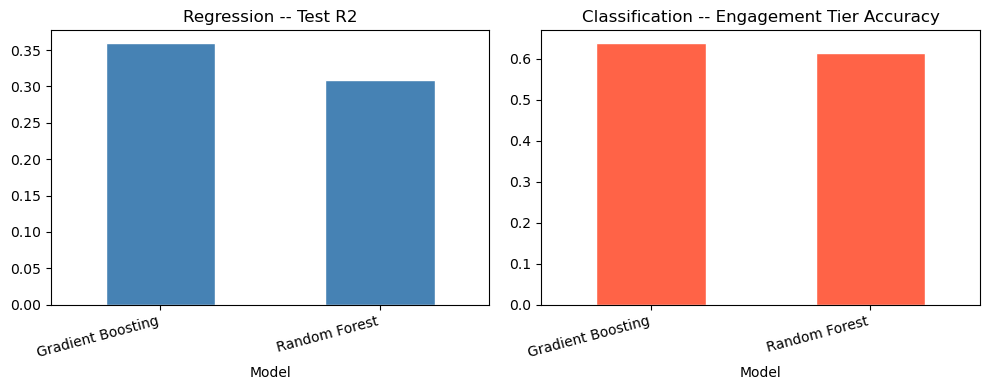


[Sample #0]
Actual buzz_score  : 0.00
Predicted buzz     : 3.34
Engagement Tier    : Low
Probabilities      : Low=79.0%  Mid=18.3%  High=2.7%


In [17]:
reg_models = {'Random Forest': (rf_reg, X_reg_test), 'Gradient Boosting': (gb_reg, X_reg_test)}
reg_results = [{'Model': name,
                'Test R2':   round(r2_score(y_reg_test, m.predict(X)), 4),
                'Test RMSE': round(np.sqrt(mean_squared_error(y_reg_test, m.predict(X))), 4)}
               for name, (m, X) in reg_models.items()]
reg_df = pd.DataFrame(reg_results).sort_values('Test R2', ascending=False).reset_index(drop=True)
print('=== REGRESSION ==='); print(reg_df)

clf_models = {'Random Forest': (rf_clf, X_clf_test), 'Gradient Boosting': (gb_clf, X_clf_test)}
clf_results = [{'Model': name,
                'Accuracy': round(accuracy_score(y_clf_test, m.predict(X)), 4),
                'F1 Score': round(f1_score(y_clf_test, m.predict(X), average='weighted'), 4)}
               for name, (m, X) in clf_models.items()]
clf_df = pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('\n=== CLASSIFICATION (Low / Mid / High Engagement) ==='); print(clf_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
reg_df.plot(x='Model', y='Test R2', kind='bar', ax=axes[0],
    legend=False, color='steelblue', edgecolor='white')
axes[0].set_title('Regression -- Test R2')
axes[0].set_xticklabels(reg_df['Model'], rotation=15, ha='right')
clf_df.plot(x='Model', y='Accuracy', kind='bar', ax=axes[1],
    legend=False, color='tomato', edgecolor='white')
axes[1].set_title('Classification -- Engagement Tier Accuracy')
axes[1].set_xticklabels(clf_df['Model'], rotation=15, ha='right')
plt.tight_layout(); plt.show()

sample_idx = 0
actual_val = y_reg_test[sample_idx]
pred_val   = gb_reg.predict(X_reg_test.iloc[[sample_idx]])[0]
pred_tier  = ['Low','Mid','High'][gb_clf.predict(X_clf_test.iloc[[sample_idx]])[0]]
proba      = gb_clf.predict_proba(X_clf_test.iloc[[sample_idx]])[0]

print(f'\n[Sample #{sample_idx}]')
print(f'Actual buzz_score  : {actual_val:.2f}')
print(f'Predicted buzz     : {pred_val:.2f}')
print(f'Engagement Tier    : {pred_tier}')
print(f'Probabilities      : Low={proba[0]:.1%}  Mid={proba[1]:.1%}  High={proba[2]:.1%}')
